# 🌲 Supervised Intrusion Detection — Random Forest Baseline
## CSE-CIC-IDS2018 Dataset | AWS t3.large Optimized | With Full Caching

**Project Goal:** Train a Random Forest classifier to distinguish between benign traffic and known attack patterns, then evaluate its robustness against **unseen zero-day attacks**.

**Pipeline Overview:**
1. Load & merge all 10 CSVs → cached as `cleaned_data.parquet`
2. Clean & preprocess features → cached in parquet
3. **Seen vs Unseen Split** → cached as `.npy` arrays
4. Train Random Forest → cached as `.joblib` model
5. Evaluate & visualize (Confusion Matrix, Zero-Day Recall, ROC/PR Curves)

**Environment:** Ubuntu 24.04 | EC2 t3.large | 8GB RAM + 16GB swap | Python 3.10+

## Cell 1 — Install / Verify Dependencies

In [1]:
import sys, platform, os
import numpy as np
import pandas as pd
import sklearn, matplotlib, seaborn

print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Scikit     : {sklearn.__version__}")

mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"\nSystem RAM : {mem_bytes / (1024**3):.1f} GB")

Python     : 3.12.3
NumPy      : 2.4.4
Pandas     : 3.0.2
Scikit     : 1.8.0

System RAM : 7.6 GB


## Cell 2 — Configuration & Cache Paths

In [2]:
import os
from pathlib import Path

DATA_PATH  = os.path.expanduser("~/ids2018/data")
OUTPUT_DIR = os.path.expanduser("~/ids2018/outputs")
CACHE_DIR  = os.path.expanduser("~/ids2018/cache")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

CACHE_PARQUET      = os.path.join(CACHE_DIR, "cleaned_data.parquet")
CACHE_X_TRAIN      = os.path.join(CACHE_DIR, "rf_X_train.npy")
CACHE_X_TEST       = os.path.join(CACHE_DIR, "rf_X_test.npy")
CACHE_Y_TRAIN      = os.path.join(CACHE_DIR, "rf_y_train.npy")
CACHE_Y_TEST       = os.path.join(CACHE_DIR, "rf_y_test.npy")
CACHE_LABELS_TEST  = os.path.join(CACHE_DIR, "rf_labels_test.npy")
CACHE_MODEL        = os.path.join(OUTPUT_DIR, "rf_model.joblib")

FORCE_RERUN = False
SEED = 42

# ── Seen vs Unseen Attacks ──────────────────────────────────────────────────
# These are seen during training
SEEN_ATTACKS = ["dos attacks-hulk", "ssh-bruteforce"]
# These are held out for zero-day evaluation
UNSEEN_ATTACKS = ["bot", "dos attacks-slowhttptest", "infilteration"]

# ── RF Hyperparameters ──────────────────────────────────────────────────────
N_ESTIMATORS = 100
MAX_DEPTH    = 20    # Capped to save memory on 8GB RAM

print(f"Data path  : {DATA_PATH}")
print(f"FORCE_RERUN: {FORCE_RERUN}")

Data path  : /home/ubuntu/ids2018/data
FORCE_RERUN: False


## Cell 3 — Imports & Helpers

In [3]:
import warnings, gc, time, joblib
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.switch_backend("Agg")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)

def save_and_show(fig, filename: str):
    save_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=save_path))

def cache_exists(*paths) -> bool:
    if FORCE_RERUN: return False
    return all(os.path.exists(p) for p in paths)

print("Helpers ready ✓")

Helpers ready ✓


## Stage 1+2: Load & Clean *(Shared Logic)*

In [4]:
if cache_exists(CACHE_PARQUET):
    print(f"CACHE HIT — loading cleaned data: {CACHE_PARQUET}")
    df = pd.read_parquet(CACHE_PARQUET)
else:
    # Note: If this fails, visit autoencoder notebook to generate common parquet.
    print("CACHE MISS — please run autoencoder_model.ipynb first to generate cleaned_data.parquet")
    print("OR paste chunk-cleaning logic here if you want independent processing.")
    raise FileNotFoundError(CACHE_PARQUET)

print(f"Loaded {len(df):,} rows.")

CACHE HIT — loading cleaned data: /home/ubuntu/ids2018/cache/cleaned_data.parquet
Loaded 3,215,110 rows.


## Stage 3 — Zero-Day Split

In [5]:
STAGE3_FILES = [CACHE_X_TRAIN, CACHE_X_TEST, CACHE_Y_TRAIN, CACHE_Y_TEST, CACHE_LABELS_TEST]

if cache_exists(*STAGE3_FILES):
    print("CACHE HIT — loading split arrays...")
    X_train = np.load(CACHE_X_TRAIN)
    X_test  = np.load(CACHE_X_TEST)
    y_train = np.load(CACHE_Y_TRAIN)
    y_test  = np.load(CACHE_Y_TEST)
    labels_test = np.load(CACHE_LABELS_TEST, allow_pickle=True)
else:
    print("CACHE MISS — splitting for seen/unseen attacks...")
    
    # Standardize label col access
    LABEL_COL = "Label"
    if LABEL_COL not in df.columns: LABEL_COL = "label"
    
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.lower().str.strip()
    
    # Split pools
    benign_df = df[df[LABEL_COL] == "benign"]
    seen_df   = df[df[LABEL_COL].isin(SEEN_ATTACKS)]
    unseen_df = df[df[LABEL_COL].isin(UNSEEN_ATTACKS)]
    
    print(f"Benign: {len(benign_df):,}")
    print(f"Seen Attacks: {len(seen_df):,}")
    print(f"Unseen (Zero-Day): {len(unseen_df):,}")
    
    # Training: 80% Benign + 80% Seen Attacks
    B_train, B_test = train_test_split(benign_df, test_size=0.2, random_state=SEED)
    S_train, S_test = train_test_split(seen_df,   test_size=0.2, random_state=SEED)
    
    train_pool = pd.concat([B_train, S_train], ignore_index=True).sample(frac=1, random_state=SEED)
    test_pool  = pd.concat([B_test, S_test, unseen_df], ignore_index=True).sample(frac=1, random_state=SEED)
    
    FEATURE_COLS = [c for c in df.columns if c not in [LABEL_COL, "is_attack", "attack_type"]]
    
    X_train = train_pool[FEATURE_COLS].values.astype(np.float32)
    y_train = (train_pool[LABEL_COL] != "benign").astype(int).values
    
    X_test  = test_pool[FEATURE_COLS].values.astype(np.float32)
    y_test  = (test_pool[LABEL_COL] != "benign").astype(int).values
    labels_test = test_pool[LABEL_COL].values
    
    print("Saving arrays...")
    np.save(CACHE_X_TRAIN, X_train)
    np.save(CACHE_X_TEST,  X_test)
    np.save(CACHE_Y_TRAIN, y_train)
    np.save(CACHE_Y_TEST,  y_test)
    np.save(CACHE_LABELS_TEST, labels_test)

print(f"Train set: {X_train.shape}")
print(f"Test set : {X_test.shape}")

CACHE MISS — splitting for seen/unseen attacks...
Benign: 2,050,783
Seen Attacks: 181,795
Unseen (Zero-Day): 234,980
Saving arrays...
Train set: (1786062, 68)
Test set : (681496, 68)


## Stage 4 — Train Random Forest

In [7]:
if cache_exists(CACHE_MODEL):
    print("CACHE HIT — loading fitted Random Forest...")
    rf = joblib.load(CACHE_MODEL)
else:
    print(f"CACHE MISS — training RF (estimators={N_ESTIMATORS}, depth={MAX_DEPTH})...")
    rf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, 
        max_depth=MAX_DEPTH, 
        random_state=SEED, 
        n_jobs=-1,
        verbose=1
    )
    t0 = time.time()
    rf.fit(X_train, y_train)
    print(f"Training took {time.time()-t0:.1f}s")
    
    print("Saving model...")
    joblib.dump(rf, CACHE_MODEL)

print("RF Model ready.")

CACHE HIT — loading fitted Random Forest...
RF Model ready.


## Stage 5 — Evaluation & Visualization

In [9]:
print("Predicting on test set...")
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n--- Overall Classification Report ---")
print(classification_report(y_test, y_pred))

auroc = roc_auc_score(y_test, y_prob)
ap    = average_precision_score(y_test, y_prob)
print(f"ROC-AUC: {auroc:.4f}")
print(f"Avg Precision: {ap:.4f}")

Predicting on test set...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    3.2s finished



--- Overall Classification Report ---
              precision    recall  f1-score   support

           0       0.64      1.00      0.78    410157
           1       1.00      0.13      0.24    271339

    accuracy                           0.66    681496
   macro avg       0.82      0.57      0.51    681496
weighted avg       0.78      0.66      0.56    681496

ROC-AUC: 0.5680
Avg Precision: 0.4813


In [10]:
print("--- Per-Attack Accuracy (Zero-Day Readiness) ---")

for attack in UNSEEN_ATTACKS + SEEN_ATTACKS:
    mask = (labels_test == attack)
    if mask.sum() == 0: continue
    
    acc = (y_pred[mask] == 1).mean()
    status = "[UNSEEN]" if attack in UNSEEN_ATTACKS else "[SEEN]  "
    print(f"  {status} {attack:<25} : {acc*100:>6.2f}% detection")

--- Per-Attack Accuracy (Zero-Day Readiness) ---
  [UNSEEN] bot                       :   0.00% detection
  [UNSEEN] dos attacks-slowhttptest  :  23.64% detection
  [UNSEEN] infilteration             :   0.00% detection
  [SEEN]   dos attacks-hulk          :  99.98% detection
  [SEEN]   ssh-bruteforce            :  99.99% detection


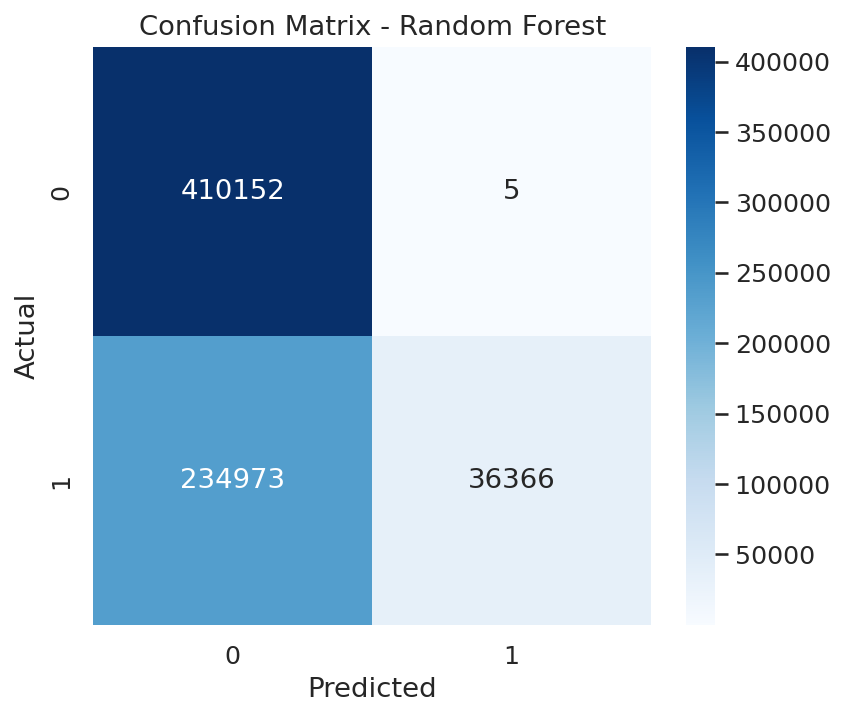

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix - Random Forest")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
save_and_show(fig, "rf_confusion_matrix.png")

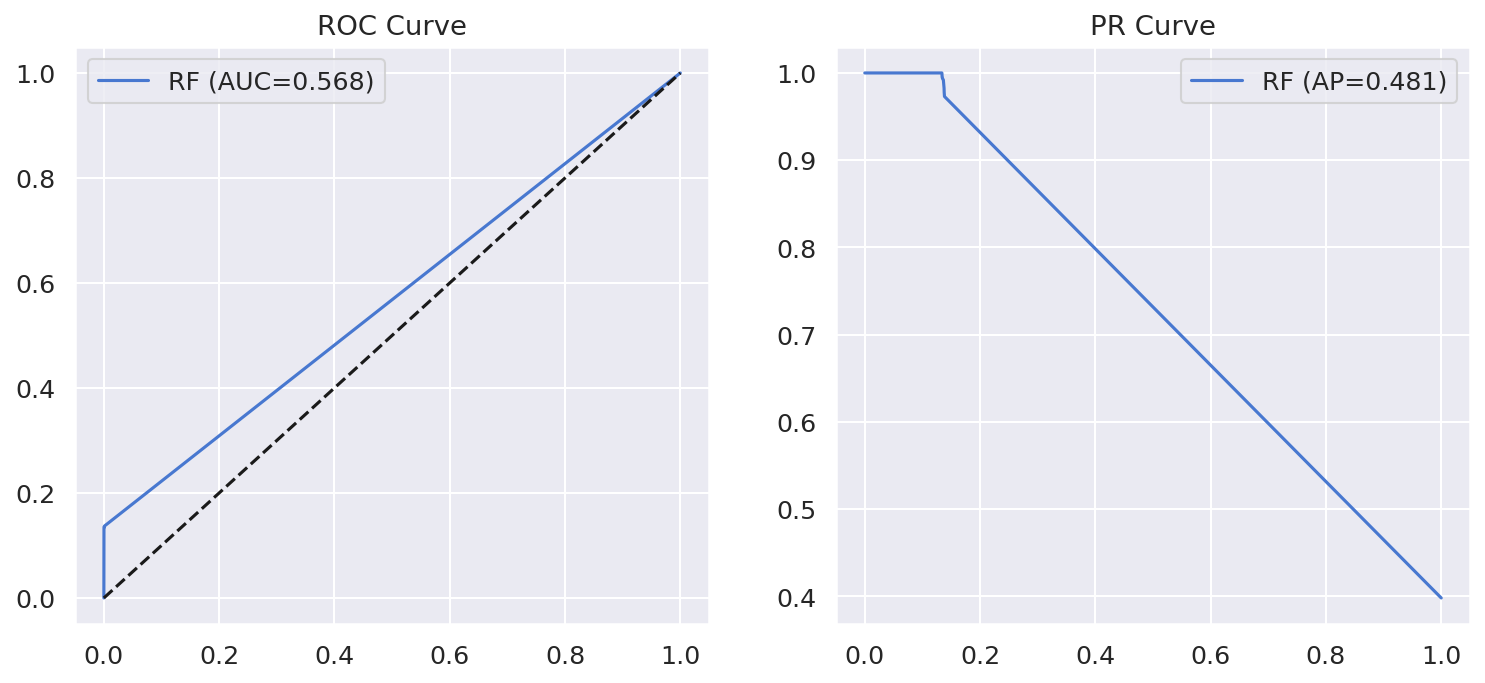

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, label=f"RF (AUC={auroc:.3f})")
ax1.plot([0,1],[0,1], 'k--')
ax1.set_title("ROC Curve")
ax1.legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, label=f"RF (AP={ap:.3f})")
ax2.set_title("PR Curve")
ax2.legend()

save_and_show(fig, "rf_curves.png")